# **UFO Sightings - Data Cleaning & Wrangling**

**Core dataset:** `scrubbed.csv`  
**Auxiliary dataset:** `complete.csv` (used only for enrichment)

Goals:

- Fix data types (temporal, quantitative, categorical) in `scrubbed.csv`
- Handle missing & inconsistent values
- Normalize categories (especially `shape`)
- Engineer attributes for visualization:
  - temporal: year, month, hour, weekday, day/night, weekend
  - duration classes
  - simple geographic groupings
- Enrich missing location fields in `scrubbed.csv` from `complete.csv`
  (country, state, latitude, longitude) where safely possible
- Run quick visual checks to validate transformations and reveal basic trends
- Export a single clean table: `ufo_cleaned.csv`


### Necessary Imports and Installation

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

### Load Datasets - Complete and Scrubbed

In [31]:
scrub = pd.read_csv("../raw/scrubbed.csv", engine='python', on_bad_lines='skip')
comp  = pd.read_csv("../raw/complete.csv", engine='python', on_bad_lines='skip')

scrub.shape, comp.shape

((80332, 11), (88679, 11))

In [ ]:
# Common Columns
common_cols = sorted(set(scrub.columns) & set(comp.columns))
common_cols

['city',
 'comments',
 'country',
 'date posted',
 'datetime',
 'duration (hours/min)',
 'duration (seconds)',
 'latitude',
 'longitude',
 'shape',
 'state']

In [33]:
# Assign Row ID
scrub = scrub.reset_index(drop=True)
comp  = comp.reset_index(drop=True)

scrub["row_id"] = scrub.index
comp["row_id"]  = comp.index

`scrubbed.csv` was derived from `complete.csv` with same row order (common in NUFORC releases).

### Basic type fixes & datetime parsing

In [34]:
# Parse Datetime for Scrubbed
df = scrub.copy()

df["datetime_parsed"] = pd.to_datetime(df["datetime"], errors="coerce")

# handle posting date if present
for col in ["date posted", "posted", "posted_date"]:
    if col in df.columns:
        df["posted_parsed"] = pd.to_datetime(df[col], errors="coerce")
        break  # first found

In [35]:
# Temporal features
df["year"]    = df["datetime_parsed"].dt.year
df["month"]   = df["datetime_parsed"].dt.month
df["day"]     = df["datetime_parsed"].dt.day
df["hour"]    = df["datetime_parsed"].dt.hour
df["weekday"] = df["datetime_parsed"].dt.dayofweek  # 0=Mon
df["is_weekend"] = df["weekday"].isin([5, 6])

# simple day/night: 20–23 and 0–4 treated as "night"
df["is_night"] = df["hour"].between(20, 23) | df["hour"].between(0, 4)

df[["datetime_parsed", "year", "month", "hour", "weekday", "is_weekend", "is_night"]].head()

,datetime_parsed,year,month,hour,weekday,is_weekend,is_night
0,1949-10-10 20:30:00,1949.0,10.0,20.0,0.0,False,True
1,1949-10-10 21:00:00,1949.0,10.0,21.0,0.0,False,True
2,1955-10-10 17:00:00,1955.0,10.0,17.0,0.0,False,False
3,1956-10-10 21:00:00,1956.0,10.0,21.0,2.0,False,True
4,1960-10-10 20:00:00,1960.0,10.0,20.0,0.0,False,True


### Duration field fixing

In [36]:
# Duration Cleaning
duration_col = None
for col in df.columns:
    if "duration" in col.lower() and "second" in col.lower():
        duration_col = col
        break

duration_col

'duration (seconds)'

In [37]:
# Parse numeric duration & inspect
df["duration_sec"] = pd.to_numeric(
    df[duration_col],
    errors="coerce"
)

df["duration_sec"].describe(percentiles=[0.5, 0.75, 0.9, 0.99])


count    8.032900e+04
mean     9.017226e+03
std      6.202284e+05
min      1.000000e-03
50%      1.800000e+02
75%      6.000000e+02
90%      1.800000e+03
99%      1.440000e+04
max      9.783600e+07
Name: duration_sec, dtype: float64

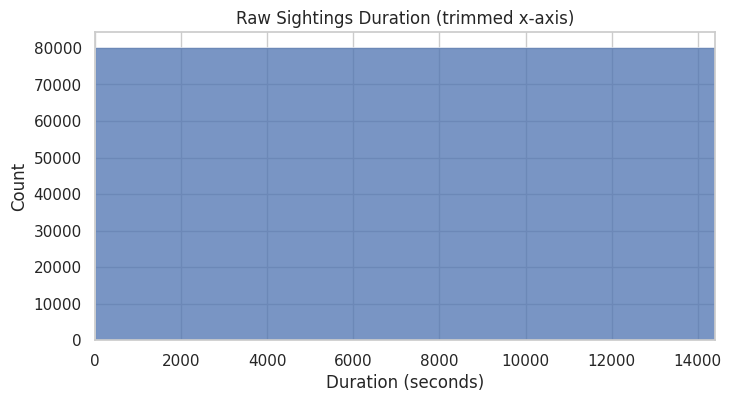

In [40]:
# Visualize Duration Distribution (raw)
plt.figure(figsize=(8,4))
sns.histplot(df["duration_sec"], bins=100)
plt.xlim(0, df["duration_sec"].quantile(0.99))  # trim extreme for visibility
plt.xlabel("Duration (seconds)")
plt.title("Raw Sightings Duration (trimmed x-axis)")
plt.show()

In [41]:
# Cap extreme durations for analysis
cap_value = df["duration_sec"].quantile(0.99)
cap_value

df["duration_sec_capped"] = df["duration_sec"].clip(upper=cap_value)
df[["duration_sec", "duration_sec_capped"]].describe()

,duration_sec,duration_sec_capped
count,8.032900e+04,80329.000000
mean,9.017226e+03,841.818571
std,6.202284e+05,2059.949214
min,1.000000e-03,0.001000
25%,3.000000e+01,30.000000
50%,1.800000e+02,180.000000
75%,6.000000e+02,600.000000
max,9.783600e+07,14400.000000


In [42]:
# Create duration classess
bins   = [0, 10, 60, 300, np.inf]
labels = ["<10s", "10-60s", "1-5min", ">5min"]

df["duration_class"] = pd.cut(
    df["duration_sec_capped"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["duration_class"].value_counts()


duration_class
>5min     26900
1-5min    23979
10-60s    16092
<10s      13358
Name: count, dtype: int64

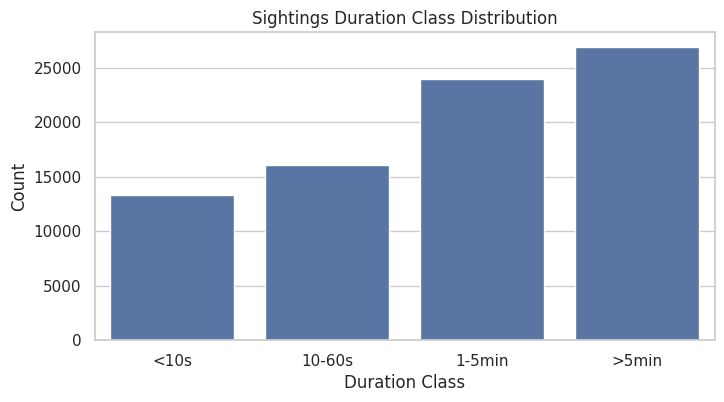

In [43]:
# Duration class bar chart
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="duration_class", order=labels)
plt.xlabel("Duration Class")
plt.ylabel("Count")
plt.title("Sightings Duration Class Distribution")
plt.show()

### Shape cleaning / normalization

In [44]:
# Normalize raw shape text
df["shape_raw"] = df["shape"].astype(str).str.lower().str.strip()

shape_counts = df["shape_raw"].value_counts(dropna=False)
shape_counts.head(20)


shape_raw
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
nan           1932
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
Name: count, dtype: int64

In [45]:
# Map variant labels & handle missing
shape_map = {
    "light": "light",
    "circle": "circle",
    "sphere": "sphere",
    "disk": "disk",
    "disc": "disk",
    "triangle": "triangle",
    "fireball": "fireball",
    "chevron": "chevron",
    "cigar": "cigar",
    "flash": "flash",
    "formation": "formation",
    "rectangle": "rectangle",
    "delta": "triangle",   
    "changed": "changing",
}

df["shape_clean"] = df["shape_raw"].replace(shape_map)
df["shape_clean"] = df["shape_clean"].replace("nan", np.nan)
df["shape_clean"] = df["shape_clean"].fillna("unknown")

df["shape_clean"].value_counts().head(20)

shape_clean
light        16565
triangle      7872
circle        7608
unknown       7516
fireball      6208
other         5649
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1963
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
Name: count, dtype: int64

In [46]:
# Fold rare shapes into “other/rare”
shape_counts = df["shape_clean"].value_counts()
rare_shapes = shape_counts[shape_counts < 50].index

df["shape_final"] = df["shape_clean"].replace(
    {s: "other/rare" for s in rare_shapes}
)

df["shape_final"].value_counts()

shape_final
light         16565
triangle       7872
circle         7608
unknown        7516
fireball       6208
other          5649
sphere         5387
disk           5213
oval           3733
formation      2457
cigar          2057
changing       1963
flash          1328
rectangle      1297
cylinder       1283
diamond        1178
chevron         952
egg             759
teardrop        750
cone            316
cross           233
other/rare        8
Name: count, dtype: int64

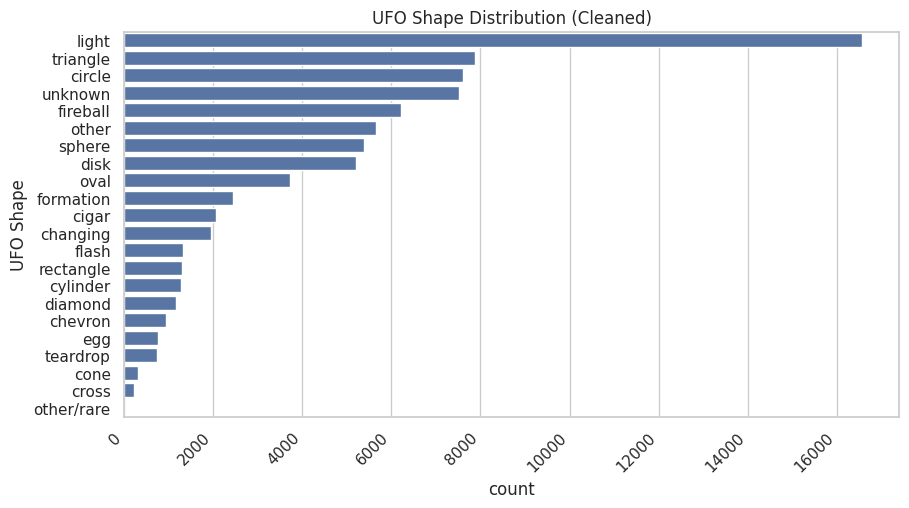

In [47]:
# Visualize cleaned shape distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="shape_final", order=df["shape_final"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.ylabel("UFO Shape")
plt.title("UFO Shape Distribution (Cleaned)")
plt.show()

### Geo enrichment from `complete.csv`

In [48]:
# Geo fields
geo_cols = ["city", "state", "country", "latitude", "longitude"]

scrub_geo = scrub[geo_cols + ["row_id"]].head(10)
comp_geo  = comp[geo_cols + ["row_id"]].head(10)

scrub_geo, comp_geo


(                   city state country   latitude   longitude  row_id
 0            san marcos    tx      us  29.883056  -97.941111       0
 1          lackland afb    tx     NaN  29.384210  -98.581082       1
 2  chester (uk/england)   NaN      gb  53.200000   -2.916667       2
 3                  edna    tx      us  28.978333  -96.645833       3
 4               kaneohe    hi      us  21.418056 -157.803611       4
 5               bristol    tn      us  36.595000  -82.188889       5
 6    penarth (uk/wales)   NaN      gb  51.434722   -3.180000       6
 7               norwalk    ct      us  41.117500  -73.408333       7
 8             pell city    al      us  33.586111  -86.286111       8
 9              live oak    fl      us  30.294722  -82.984167       9,
                    city state country   latitude   longitude  row_id
 0            san marcos    tx      us  29.883056  -97.941111       0
 1          lackland afb    tx     NaN  29.384210  -98.581082       1
 2  chester (uk/eng

In [49]:
# Merge geo columns from complete to fill missing
# select only geo columns + row_id from complete
comp_geo = comp[["row_id"] + geo_cols].copy()
comp_geo = comp_geo.add_suffix("_comp")
comp_geo = comp_geo.rename(columns={"row_id_comp": "row_id"})

df = df.merge(comp_geo, on="row_id", how="left")

df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude,row_id,datetime_parsed,posted_parsed,year,month,day,hour,weekday,is_weekend,is_night,duration_sec,duration_sec_capped,duration_class,shape_raw,shape_clean,shape_final,city_comp,state_comp,country_comp,latitude_comp,longitude_comp
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111,0,1949-10-10 20:30:00,2004-04-27,1949.0,10.0,10.0,20.0,0.0,False,True,2700.0,2700.0,>5min,cylinder,cylinder,cylinder,san marcos,tx,us,29.883056,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082,1,1949-10-10 21:00:00,2005-12-16,1949.0,10.0,10.0,21.0,0.0,False,True,7200.0,7200.0,>5min,light,light,light,lackland afb,tx,NaN,29.384210,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667,2,1955-10-10 17:00:00,2008-01-21,1955.0,10.0,10.0,17.0,0.0,False,False,20.0,20.0,10-60s,circle,circle,circle,chester (uk/england),NaN,gb,53.200000,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833,3,1956-10-10 21:00:00,2004-01-17,1956.0,10.0,10.0,21.0,2.0,False,True,20.0,20.0,10-60s,circle,circle,circle,edna,tx,us,28.978333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611,4,1960-10-10 20:00:00,2004-01-22,1960.0,10.0,10.0,20.0,0.0,False,True,900.0,900.0,>5min,light,light,light,kaneohe,hi,us,21.418056,-157.803611


In [52]:
# Combine primary & backup values
def coalesce(primary, backup):
    """Use primary if not null, otherwise backup."""
    return primary.combine_first(backup)

df["city_clean"]  = coalesce(df["city"],  df["city_comp"])
df["state_clean"] = coalesce(df["state"], df["state_comp"])
df["country_clean"] = coalesce(df["country"], df["country_comp"])
df["lat_clean"]   = coalesce(df.get("latitude"),  df.get("latitude_comp"))
df["lon_clean"]   = coalesce(df.get("longitude"), df.get("longitude_comp"))

df[["city", "city_comp", "city_clean"]].head(10)


,city,city_comp,city_clean
0,san marcos,san marcos,san marcos
1,lackland afb,lackland afb,lackland afb
2,chester (uk/england),chester (uk/england),chester (uk/england)
3,edna,edna,edna
4,kaneohe,kaneohe,kaneohe
5,bristol,bristol,bristol
6,penarth (uk/wales),penarth (uk/wales),penarth (uk/wales)
7,norwalk,norwalk,norwalk
8,pell city,pell city,pell city
9,live oak,live oak,live oak


In [68]:
df[["city_clean","state_clean","country_clean","lat_clean","lon_clean"]].isna().mean()

city_clean       0.000000
state_clean      0.000000
country_clean    0.000000
lat_clean        0.000000
lon_clean        0.000000
comments         0.000188
dtype: float64

In [54]:
# Simple US / non-US & region grouping
df["country_clean"] = df["country_clean"].str.lower().str.strip()
df["state_clean"]   = df["state_clean"].str.lower().str.strip()

df["is_us"] = df["country_clean"].eq("us")

us_region_map = {
    # West
    "ca": "west", "or": "west", "wa": "west", "nv": "west", "az": "west",
    "ut": "west", "id": "west", "ak": "west", "hi": "west",
    # Midwest
    "nd": "midwest", "sd": "midwest", "ne": "midwest", "ks": "midwest",
    "mn": "midwest", "ia": "midwest", "mo": "midwest", "wi": "midwest",
    "il": "midwest", "in": "midwest", "mi": "midwest", "oh": "midwest",
    # South
    "tx": "south", "ok": "south", "ar": "south", "la": "south", "ms": "south",
    "al": "south", "tn": "south", "ky": "south", "ga": "south", "fl": "south",
    "sc": "south", "nc": "south", "va": "south", "wv": "south", "md": "south",
    "de": "south",
    # Northeast
    "ny": "northeast", "pa": "northeast", "nj": "northeast", "ct": "northeast",
    "ri": "northeast", "ma": "northeast", "vt": "northeast", "nh": "northeast",
    "me": "northeast", "dc": "northeast"
}

df["us_region"] = df["state_clean"].map(us_region_map)
df["us_region"].value_counts(dropna=False)

us_region
west         22871
south        21842
midwest      15657
northeast    12304
NaN           7658
Name: count, dtype: int64

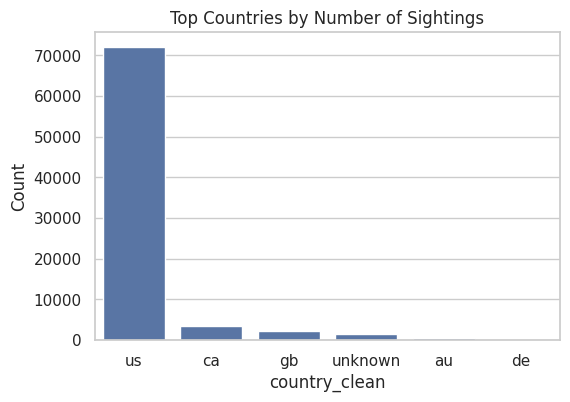

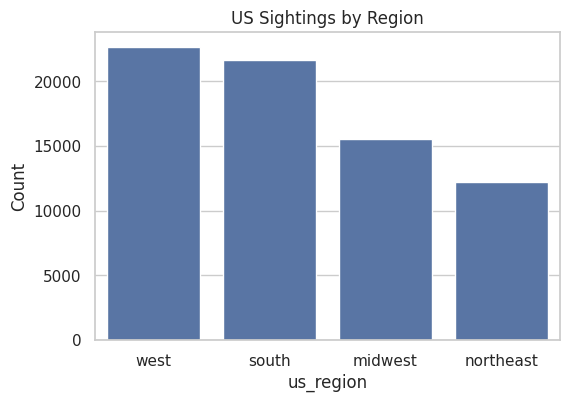

In [58]:
# Geo trend: top countries & US regions

# top countries
country_counts = df["country_clean"].value_counts().head(8)

plt.figure(figsize=(6,4))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title("Top Countries by Number of Sightings")
plt.ylabel("Count")
plt.show()

# US regions (if present)
if df["us_region"].notna().any():
    region_counts = df["us_region"].value_counts()
    plt.figure(figsize=(6,4))
    sns.barplot(x=region_counts.index, y=region_counts.values)
    plt.title("US Sightings by Region")
    plt.ylabel("Count")
    plt.show()


### Missing Values handling

In [67]:
# 1. Drop rows with no usable datetime
df = df[df["datetime_parsed"].notna()].copy()

# 2. City / State / Country after enrichment
df["city_clean"] = df["city_clean"].fillna("unknown_city")
df["state_clean"] = df["state_clean"].fillna("unknown")
df["country_clean"] = df["country_clean"].fillna("unknown")

# 3. Shape missing → unknown
df["shape_clean"] = df["shape_clean"].fillna("unknown")

# 4. Duration missing
df["duration_sec"] = df["duration_sec"].fillna(np.nan)  # keep numeric NaN

# duration_class: add unknown category
df["duration_class"] = df["duration_class"].astype(object)
df.loc[df["duration_class"].isna(), "duration_class"] = "unknown_duration"

# 5. Lat/Lon — DO NOT impute, keep NaN (honest missing)

df["lat_clean"] = df["lat_clean"].astype(float)
df["lon_clean"] = df["lon_clean"].astype(float)

# 6. Comments — missing to empty string
df["comments_clean"] = df["comments_clean"].fillna("")


### Temporal trends

In [ ]:
# Yearly counts
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(year_counts.index, year_counts.values, marker="o", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Number of sightings")
plt.title("Sightings Over Time (Yearly)")
plt.show()

In [ ]:
# Hour-of-day counts
hour_counts = df["hour"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.xlabel("Hour of day")
plt.ylabel("Number of sightings")
plt.title("Sightings by Hour (0–23)")
plt.show()

### Text Cleaning

In [64]:
df["comments_clean"] = (
    df["comments"]
    .astype(str).fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["comments_clean"].str.len().describe()

count    79638.000000
mean        82.605126
std         38.815613
min          1.000000
25%         50.000000
50%         79.000000
75%        119.000000
max        246.000000
Name: comments_clean, dtype: float64

In [65]:
final_cols = [
    # time
    "datetime_parsed", "year", "month", "day", "hour",
    "weekday", "is_weekend", "is_night",
    # geo
    "city_clean", "state_clean", "country_clean",
    "lat_clean", "lon_clean", "is_us", "us_region",
    # UFO attributes
    "shape_final",
    "duration_sec_capped", "duration_class",
    # text
    "comments_clean"
]

ufo_clean = df[final_cols].rename(columns={
    "datetime_parsed": "datetime",
    "city_clean": "city",
    "state_clean": "state",
    "country_clean": "country",
    "lat_clean": "latitude",
    "lon_clean": "longitude",
    "shape_final": "shape",
    "duration_sec_capped": "duration_sec"
})

ufo_clean.head()
ufo_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79638 entries, 0 to 80331
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        79638 non-null  datetime64[ns]
 1   year            79638 non-null  float64       
 2   month           79638 non-null  float64       
 3   day             79638 non-null  float64       
 4   hour            79638 non-null  float64       
 5   weekday         79638 non-null  float64       
 6   is_weekend      79638 non-null  bool          
 7   is_night        79638 non-null  bool          
 8   city            79638 non-null  object        
 9   state           79638 non-null  object        
 10  country         79638 non-null  object        
 11  latitude        79638 non-null  float64       
 12  longitude       79638 non-null  float64       
 13  is_us           79638 non-null  bool          
 14  us_region       72057 non-null  object        
 15  shape  

In [71]:
# Export
ufo_clean.to_csv("../processed/ufo_cleaned.csv", index=False)
print("Saved cleaned dataset with shape:", ufo_clean.shape)

Saved cleaned dataset with shape: (79638, 19)
